# PantryPlate — Week 1 EDA & Feasibility Analysis

**Purpose:** the Week 1 sanity checks confirmed the dataset *exists* and parses. This notebook asks the harder question: **does the data actually support what PantryPlate is trying to do?**

PantryPlate has four functional pillars. Each one needs a different data property to work. We interrogate them in order:

| Pillar | What the data needs to provide |
|---|---|
| **Stage 1 — CF candidate generation** | Enough rating density per user that latent-factor models have signal |
| **Stage 2 — pantry matching** | Ingredient lists with consistent canonical names, meaningful overlap structure |
| **Stage 2 — nutrition targeting** | Macros that span a reasonable space so personas can hit different targets |
| **Stage 2 — diet filtering** | Dietary tags that cover the restrictions we want to support |
| **Evaluation — Useful Recall** | Held-out positives that intersect non-trivially with constraint satisfaction |

For each, we end with a **go / caution / no-go** verdict and a Week 2 implication.

## 0. Setup

In [1]:
import os
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Run from project root so 'data/raw/...' paths resolve consistently with the loader defaults
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from src.data.loader import (
    load_recipes,
    load_interactions,
    filter_active_users,
    time_based_split,
    POSITIVE_THRESHOLD,
)
from src.data.ingredients import normalize_ingredient, NUTRITION_FIELDS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = Path.cwd() / "data" / "raw"
print(f"Data dir: {DATA_DIR}")
print(f"Files present: {sorted(p.name for p in DATA_DIR.glob('*.csv')) + ['ingr_map.pkl']}")

Data dir: /Users/ikhyvicky/Documents/MITB_stuff/CS608Project2/data/raw
Files present: ['PP_recipes.csv', 'PP_users.csv', 'RAW_interactions.csv', 'RAW_recipes.csv', 'interactions_test.csv', 'interactions_train.csv', 'interactions_validation.csv', 'ingr_map.pkl']


In [2]:
# Load once — reuse throughout the notebook
recipes = load_recipes(DATA_DIR)
interactions = load_interactions(DATA_DIR)
print(f"recipes:      {len(recipes):>9,} rows")
print(f"interactions: {len(interactions):>9,} rows (after 0-star drop)")
print(f"users:        {interactions['user_id'].nunique():>9,}")
print(f"distinct rated recipes: {interactions['recipe_id'].nunique():>9,}")

recipes:        231,637 rows
interactions: 1,071,520 rows (after 0-star drop)
users:          196,098
distinct rated recipes:   226,590


## 1. Stage 1 feasibility — is there enough signal for CF?

CF models (MF, BPR, NCF) learn latent factors from co-occurrence of (user, item) pairs. They fail in two ways:
1. **Per-user sparsity** — if most users have only 1–2 ratings, there's nothing to learn from.
2. **Per-item sparsity** — if most recipes are rated by only 1–2 users, the item factor is unidentifiable.

Both distributions are typically power-law. We want to quantify the tail.

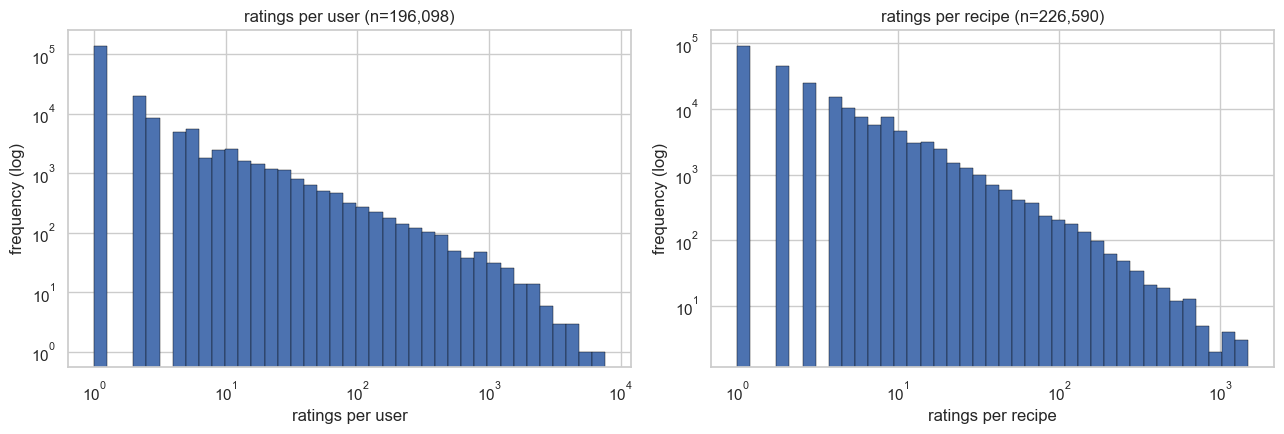


Per-USER:
  >=  1 ratings: 196,098 users  (100.0%)
  >=  2 ratings:  55,780 users  (28.4%)
  >=  5 ratings:  22,018 users  (11.2%)
  >= 10 ratings:  12,035 users  ( 6.1%)
  >= 20 ratings:   6,450 users  ( 3.3%)
  >= 50 ratings:   2,669 users  ( 1.4%)

Per-RECIPE:
  >=  1 ratings: 226,590 recipes (100.0%)
  >=  2 ratings: 134,892 recipes (59.5%)
  >=  5 ratings:  50,978 recipes (22.5%)
  >= 10 ratings:  20,060 recipes ( 8.9%)
  >= 20 ratings:   7,400 recipes ( 3.3%)
  >= 50 ratings:   1,979 recipes ( 0.9%)

User-item matrix density: 2.41e-05  (1,071,520 filled / 44,433,845,820 cells)


In [3]:
user_counts = interactions.groupby("user_id").size()
item_counts = interactions.groupby("recipe_id").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, counts, label in [
    (axes[0], user_counts, "ratings per user"),
    (axes[1], item_counts, "ratings per recipe"),
]:
    bins = np.logspace(0, np.log10(counts.max()), 40)
    ax.hist(counts, bins=bins, edgecolor="black", linewidth=0.3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(label); ax.set_ylabel("frequency (log)")
    ax.set_title(f"{label} (n={len(counts):,})")

plt.tight_layout()
plt.show()

print("\nPer-USER:")
for t in [1, 2, 5, 10, 20, 50]:
    n = (user_counts >= t).sum()
    print(f"  >= {t:>2} ratings: {n:>7,} users  ({n/len(user_counts):>5.1%})")

print("\nPer-RECIPE:")
for t in [1, 2, 5, 10, 20, 50]:
    n = (item_counts >= t).sum()
    print(f"  >= {t:>2} ratings: {n:>7,} recipes ({n/len(item_counts):>5.1%})")

# Matrix density
n_filled = len(interactions)
n_cells = interactions["user_id"].nunique() * interactions["recipe_id"].nunique()
print(f"\nUser-item matrix density: {n_filled / n_cells:.2e}  ({n_filled:,} filled / {n_cells:,} cells)")

In [4]:
# How much of the rating mass do the active users represent?
active_users = user_counts[user_counts >= 5].index
active_interactions = interactions[interactions["user_id"].isin(active_users)]

print(f"Active subset (>=5 ratings):")
print(f"  users:        {len(active_users):>8,}   ({len(active_users)/len(user_counts):.1%} of total)")
print(f"  interactions: {len(active_interactions):>8,}   ({len(active_interactions)/len(interactions):.1%} of total)")

# The active subset carries the disproportionate share of signal
print(f"\nSo ~10% of users carry ~80% of the rating mass.")
print(f"This is the population CF will actually learn from.")

Active subset (>=5 ratings):
  users:          22,018   (11.2% of total)
  interactions:  845,346   (78.9% of total)

So ~10% of users carry ~80% of the rating mass.
This is the population CF will actually learn from.


## 2. Rating signal quality — do users actually discriminate?

The sanity check showed 72% of all ratings are 5-star and 88.6% are 4+. If most users *always* rate 5 stars, then a 4-star positive threshold is meaningless and we may need to use rank-style signals (BPR-friendly) rather than ratings.

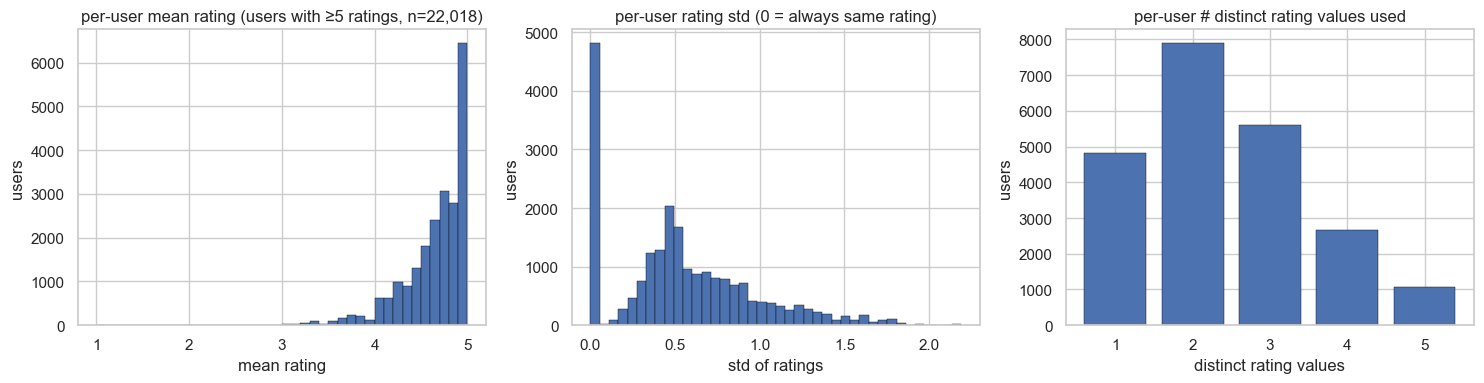

Users (≥5 ratings) who ALWAYS give the same rating: 4,809 (21.8%)
Users (≥5 ratings) who use only 1–2 distinct values: 12,694 (57.7%)
Mean of per-user mean rating: 4.65


In [5]:
# Per-user rating behavior — are they always-5 or do they discriminate?
user_stats = (
    interactions.groupby("user_id")
    .agg(n_ratings=("rating", "size"),
         mean_rating=("rating", "mean"),
         std_rating=("rating", "std"),
         n_unique=("rating", "nunique"))
)
active_stats = user_stats[user_stats["n_ratings"] >= 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(active_stats["mean_rating"], bins=40, edgecolor="black", linewidth=0.3)
axes[0].set_title(f"per-user mean rating (users with ≥5 ratings, n={len(active_stats):,})")
axes[0].set_xlabel("mean rating"); axes[0].set_ylabel("users")

axes[1].hist(active_stats["std_rating"].fillna(0), bins=40, edgecolor="black", linewidth=0.3)
axes[1].set_title("per-user rating std (0 = always same rating)")
axes[1].set_xlabel("std of ratings"); axes[1].set_ylabel("users")

uniq_dist = active_stats["n_unique"].value_counts().sort_index()
axes[2].bar(uniq_dist.index, uniq_dist.values, edgecolor="black", linewidth=0.3)
axes[2].set_title("per-user # distinct rating values used")
axes[2].set_xlabel("distinct rating values"); axes[2].set_ylabel("users")

plt.tight_layout(); plt.show()

always_same = (active_stats["n_unique"] == 1).sum()
print(f"Users (≥5 ratings) who ALWAYS give the same rating: {always_same:,} ({always_same/len(active_stats):.1%})")
print(f"Users (≥5 ratings) who use only 1–2 distinct values: "
      f"{(active_stats['n_unique'] <= 2).sum():,} ({(active_stats['n_unique'] <= 2).sum()/len(active_stats):.1%})")
print(f"Mean of per-user mean rating: {active_stats['mean_rating'].mean():.2f}")

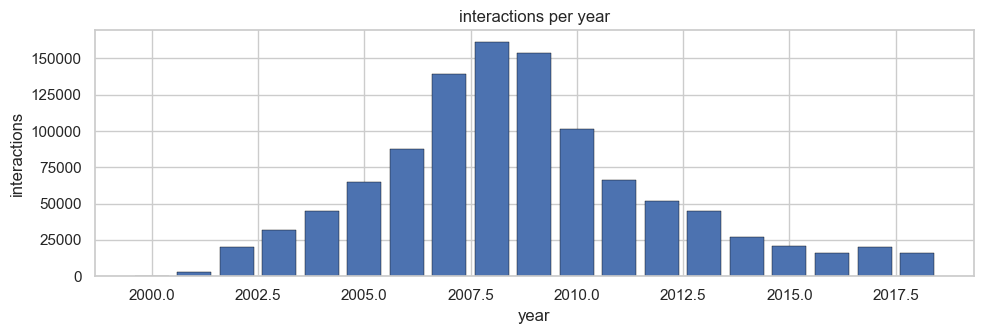

Peak year: 2008 (161,251 interactions)
Last year (2018): 16,091 interactions (10% of peak)
Implication: dataset is historical (2000–2018). Time-based split is fine, but
recent-recipe coverage is light. Cold-start for 2018 recipes will be sparser than for 2008.


In [6]:
# Is the corpus still alive? Plot ratings per year
yearly = interactions.dropna(subset=["date"]).set_index("date").resample("YE").size()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(yearly.index.year, yearly.values, edgecolor="black", linewidth=0.3)
ax.set_title("interactions per year")
ax.set_xlabel("year"); ax.set_ylabel("interactions")
plt.tight_layout(); plt.show()

peak_year = yearly.idxmax().year
print(f"Peak year: {peak_year} ({yearly.max():,} interactions)")
print(f"Last year (2018): {yearly.iloc[-1]:,} interactions ({yearly.iloc[-1]/yearly.max():.0%} of peak)")
print("Implication: dataset is historical (2000–2018). Time-based split is fine, but")
print("recent-recipe coverage is light. Cold-start for 2018 recipes will be sparser than for 2008.")

## 3. Recipe content — shape of the catalog

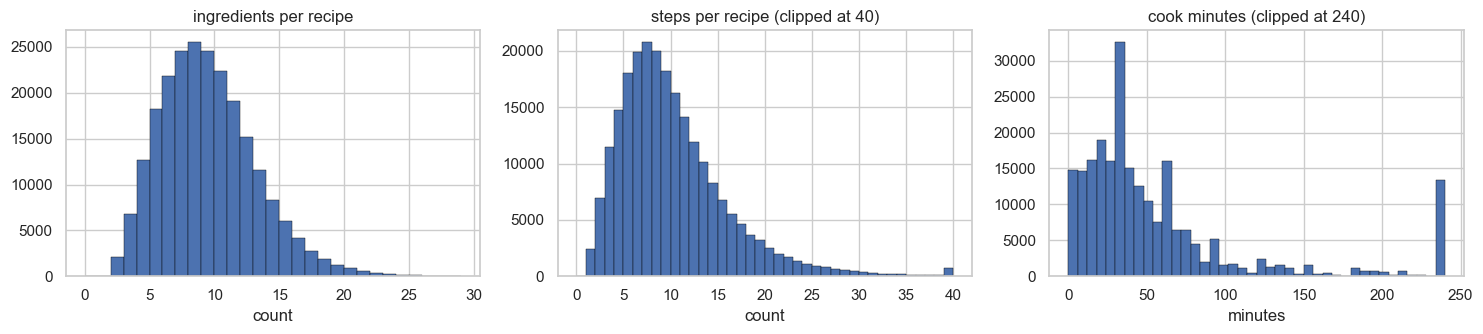

Median ingredients/recipe: 9
Median steps/recipe:       9
Median cook minutes:       40
Cook-time outliers (>240 min): 12,969 (some legitimate slow-cook, some misparsed)


In [7]:
# Ingredient count, step count, cook time — quick shape check
recipes["n_ingredients_actual"] = recipes["ingredients_parsed"].str.len()
recipes["n_steps_actual"] = recipes["steps_parsed"].str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(recipes["n_ingredients_actual"], bins=range(0, 30), edgecolor="black", linewidth=0.3)
axes[0].set_title("ingredients per recipe"); axes[0].set_xlabel("count")

axes[1].hist(recipes["n_steps_actual"].clip(upper=40), bins=range(0, 41), edgecolor="black", linewidth=0.3)
axes[1].set_title("steps per recipe (clipped at 40)"); axes[1].set_xlabel("count")

minutes = recipes["minutes"].clip(upper=240)
axes[2].hist(minutes, bins=40, edgecolor="black", linewidth=0.3)
axes[2].set_title("cook minutes (clipped at 240)"); axes[2].set_xlabel("minutes")

plt.tight_layout(); plt.show()

print(f"Median ingredients/recipe: {recipes['n_ingredients_actual'].median():.0f}")
print(f"Median steps/recipe:       {recipes['n_steps_actual'].median():.0f}")
print(f"Median cook minutes:       {recipes['minutes'].median():.0f}")
print(f"Cook-time outliers (>240 min): {(recipes['minutes'] > 240).sum():,} "
      f"(some legitimate slow-cook, some misparsed)")

## 4. Pantry-matching feasibility (Stage 2 pantry)

Stage 2 scores `s_pantry`. For this to be discriminative, two things must hold:
1. Canonical ingredient frequency must follow a long tail (so common-ingredient overlap is achievable and rare-ingredient overlap is informative).
2. A realistic user pantry should produce a meaningful spread in `s_pantry` across recipes — not all 0 (pantry too small) or all 1 (recipes too generic).

**Key refinement (added after initial analysis):** `s_pantry` is computed on **non-staple** ingredients only. Universal staples (salt, pepper, water, oil, sugar, flour, eggs, milk, butter, garlic, onion, baking powder/soda, vinegar, vanilla — ~20 items) are assumed available in every kitchen and excluded from the denominator. This avoids penalizing a recipe for needing salt that everyone has. See `src/utils/staples.py` for the canonical list. Below we compare three pantry definitions and a flexibility analysis.

In [8]:
# Compute canonical ingredient frequency across the whole catalog
# (may take ~30s due to dict lookup over ~2M ingredient mentions)
print("Canonicalizing ingredients across all recipes...")
ingr_counter: Counter = Counter()
for ings in recipes["ingredients_parsed"]:
    for raw in ings:
        canonical = normalize_ingredient(raw)
        if canonical:
            ingr_counter[canonical] += 1

print(f"Total ingredient mentions: {sum(ingr_counter.values()):,}")
print(f"Unique canonical ingredients: {len(ingr_counter):,}")
print(f"\nTop 20 most common ingredients:")
for name, c in ingr_counter.most_common(20):
    print(f"  {c:>7,}  {name}")

Canonicalizing ingredients across all recipes...


Total ingredient mentions: 2,096,582
Unique canonical ingredients: 11,282

Top 20 most common ingredients:
   85,764  salt
   55,109  butter
   51,065  egg
   48,945  onion
   44,535  sugar
   41,265  olive oil
   35,527  garlic clove
   34,914  water
   28,351  milk
   26,432  flmy
   22,319  pepper
   18,655  brown sugar
   18,087  garlic
   17,664  all-purpose flmy
   17,555  baking powder
   16,574  scallion
   15,415  salt and pepper
   14,937  parmesan cheese
   14,702  cheddar
   14,233  lemon juice


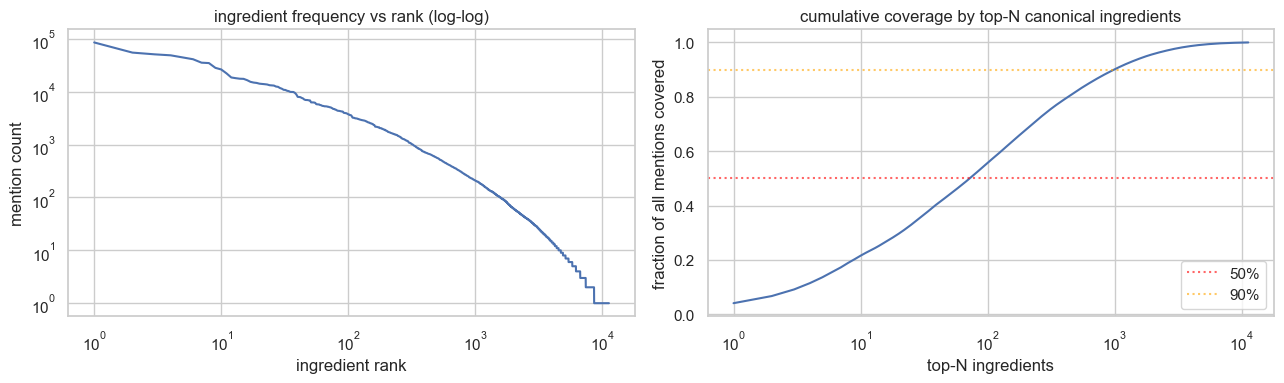

Top   73 ingredients cover 50% of all mentions
Top  431 ingredients cover 80% of all mentions
Top  990 ingredients cover 90% of all mentions


In [9]:
# Frequency distribution — confirm long tail
freqs = np.array(sorted(ingr_counter.values(), reverse=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(freqs)+1), freqs)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("ingredient rank"); axes[0].set_ylabel("mention count")
axes[0].set_title("ingredient frequency vs rank (log-log)")

# Cumulative coverage
cum = np.cumsum(freqs) / freqs.sum()
axes[1].plot(np.arange(1, len(freqs)+1), cum)
axes[1].set_xscale("log")
axes[1].set_xlabel("top-N ingredients"); axes[1].set_ylabel("fraction of all mentions covered")
axes[1].set_title("cumulative coverage by top-N canonical ingredients")
axes[1].axhline(0.5, color="red", linestyle=":", alpha=0.6, label="50%")
axes[1].axhline(0.9, color="orange", linestyle=":", alpha=0.6, label="90%")
axes[1].legend()

plt.tight_layout(); plt.show()

for pct in [0.5, 0.8, 0.9]:
    n = np.searchsorted(cum, pct) + 1
    print(f"Top {n:>4} ingredients cover {pct:.0%} of all mentions")

User pantry: 25 items (no staples)
Staples: 38 items (assumed available)
Total assumed-available: 63 items


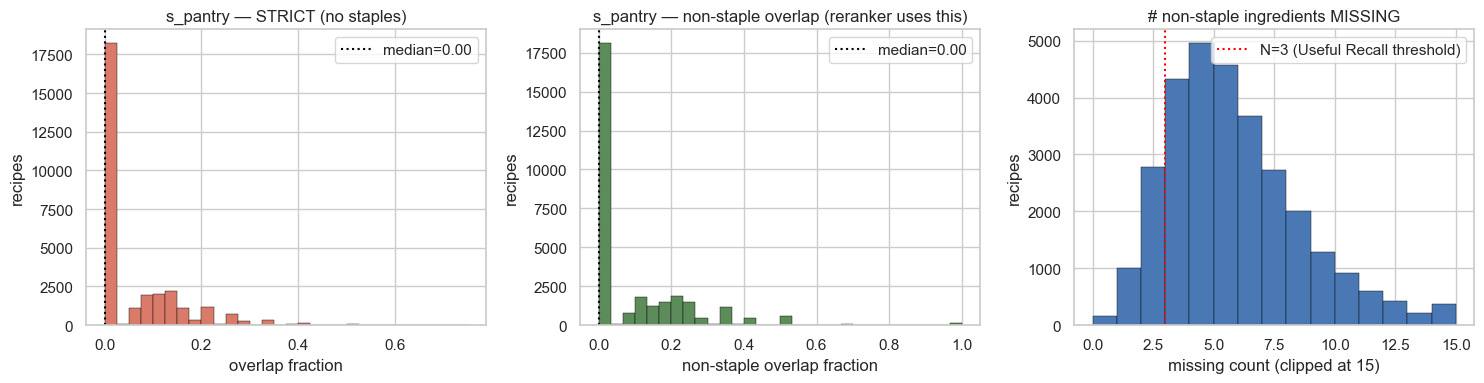


Median s_pantry — strict (no staples):  0.000
Median s_pantry — non-staple overlap:   0.000  (reranker score)

By overlap-fraction threshold (s_pantry on non-staples):
  s_pantry >=  0.3:   9.1%
  s_pantry >=  0.5:   3.0%
  s_pantry >= 0.75:   0.6%
  s_pantry >=  0.9:   0.6%

By missing-count threshold (# non-staples NOT in pantry):
  missing <= 0:   0.6%
  missing <= 1:   3.9%
  missing <= 2:  13.1%
  missing <= 3:  27.5%
  missing <= 5:  59.2%

=== TAKEAWAYS ===
1. Median s_pantry is near 0 in BOTH staples-aware and strict forms,
   because a 25-item user pantry rarely covers a recipe's 5-9 non-staple ingredients.
   This is FINE for the reranker — it discriminates between recipes for a given user.
2. For Useful Recall threshold, 'missing <= 3' (27.5%) is more usable
   than 's_pantry >= 0.5' (3.0%) — and more interpretable
   ('user would only need to buy 3 more things').
3. Recommendation: use pantry_score in the reranker (continuous, low values OK);
   use missing <= 3 as the Use

In [10]:
from src.utils.staples import STAPLES, pantry_score, missing_count

# Realistic user-specific pantry — 25 items NOT counting universal staples.
# This is what a persona would actually need to list in its JSON.
USER_PANTRY = {
    "chicken", "rice", "broccoli", "spinach", "tomato",
    "parmesan cheese", "cheddar", "mozzarella", "cream cheese",
    "ground beef", "pork", "salmon",
    "pasta", "noodles", "bread",
    "lemon", "lime", "carrot",
    "bell pepper", "mushroom",
    "yogurt", "cream", "sour cream",
    "ketchup", "mustard",
}
print(f"User pantry: {len(USER_PANTRY)} items (no staples)")
print(f"Staples: {len(STAPLES)} items (assumed available)")
print(f"Total assumed-available: {len(USER_PANTRY | STAPLES)} items")

# Sample 30K recipes for speed
sample = recipes.sample(30_000, random_state=42).copy()
sample["canon_ings"] = sample["ingredients_parsed"].apply(
    lambda L: {normalize_ingredient(i) for i in L if i}
)

# Three definitions:
#   s_strict   = old-style |ings ∩ user_pantry| / |ings| (no staples concept)
#   s_pantry   = new pantry_score: |non_staple ∩ user_pantry| / |non_staple|
#                  — this is the continuous score the reranker uses
#   missing    = count of non-staple ingredients NOT in user pantry
#                  — this is the count-based feasibility measure
def overlap_raw(ings, pantry):
    if not ings: return 0.0
    return len(ings & pantry) / len(ings)

sample["s_strict"]  = sample["canon_ings"].apply(lambda x: overlap_raw(x, USER_PANTRY))
sample["s_pantry"]  = sample["canon_ings"].apply(lambda x: pantry_score(x, USER_PANTRY))
sample["missing"]   = sample["canon_ings"].apply(lambda x: missing_count(x, USER_PANTRY))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample["s_strict"], bins=30, edgecolor="black", linewidth=0.3, color="#d97a6b")
axes[0].set_title("s_pantry — STRICT (no staples)")
axes[0].set_xlabel("overlap fraction"); axes[0].set_ylabel("recipes")
axes[0].axvline(sample["s_strict"].median(), color="black", linestyle=":",
                label=f"median={sample['s_strict'].median():.2f}")
axes[0].legend()

axes[1].hist(sample["s_pantry"], bins=30, edgecolor="black", linewidth=0.3, color="#5b8c5a")
axes[1].set_title("s_pantry — non-staple overlap (reranker uses this)")
axes[1].set_xlabel("non-staple overlap fraction"); axes[1].set_ylabel("recipes")
axes[1].axvline(sample["s_pantry"].median(), color="black", linestyle=":",
                label=f"median={sample['s_pantry'].median():.2f}")
axes[1].legend()

axes[2].hist(sample["missing"].clip(upper=15), bins=range(16), edgecolor="black", linewidth=0.3, color="#4a78b5")
axes[2].set_title("# non-staple ingredients MISSING")
axes[2].set_xlabel("missing count (clipped at 15)"); axes[2].set_ylabel("recipes")
axes[2].axvline(3, color="red", linestyle=":", label="N=3 (Useful Recall threshold)")
axes[2].legend()

plt.tight_layout(); plt.show()

# Compute summary numbers for the takeaway
med_strict  = sample["s_strict"].median()
med_pantry  = sample["s_pantry"].median()
pct_overlap_50  = (sample["s_pantry"] >= 0.5).mean()
pct_overlap_30  = (sample["s_pantry"] >= 0.3).mean()
pct_missing_3   = (sample["missing"] <= 3).mean()
pct_missing_5   = (sample["missing"] <= 5).mean()

print(f"\nMedian s_pantry — strict (no staples):  {med_strict:.3f}")
print(f"Median s_pantry — non-staple overlap:   {med_pantry:.3f}  (reranker score)")
print()
print(f"By overlap-fraction threshold (s_pantry on non-staples):")
for thr in [0.3, 0.5, 0.75, 0.9]:
    pct = (sample['s_pantry'] >= thr).mean()
    print(f"  s_pantry >= {thr:>4}: {pct:>6.1%}")
print()
print(f"By missing-count threshold (# non-staples NOT in pantry):")
for max_miss in [0, 1, 2, 3, 5]:
    pct = (sample['missing'] <= max_miss).mean()
    print(f"  missing <= {max_miss}: {pct:>6.1%}")
print()
print(f"=== TAKEAWAYS ===")
print(f"1. Median s_pantry is near 0 in BOTH staples-aware and strict forms,")
print(f"   because a 25-item user pantry rarely covers a recipe's 5-9 non-staple ingredients.")
print(f"   This is FINE for the reranker — it discriminates between recipes for a given user.")
print(f"2. For Useful Recall threshold, 'missing <= 3' ({pct_missing_3:.1%}) is more usable")
print(f"   than 's_pantry >= 0.5' ({pct_overlap_50:.1%}) — and more interpretable")
print(f"   ('user would only need to buy 3 more things').")
print(f"3. Recommendation: use pantry_score in the reranker (continuous, low values OK);")
print(f"   use missing <= 3 as the Useful Recall pantry condition.")

### 4b. Justifying the STAPLES set with ingredient frequencies

Universal staples are assumed available in every kitchen. To avoid handwaving, we check each staple in `src/utils/staples.py` against actual recipe-level ingredient frequencies in this dataset. A defensible staple should:

1. **Be common in recipes** — appears in ≥1% of the catalog (so excluding it from the pantry score actually matters)
2. **Be commonly stocked at home** — a household criterion, somewhat subjective
3. **Cross cuisines** — not tied to a single regional style

The chart below shows the top 40 ingredients (by % of recipes containing them), color-coded by whether they're in our STAPLES set. This makes the inclusion / exclusion judgments inspectable.

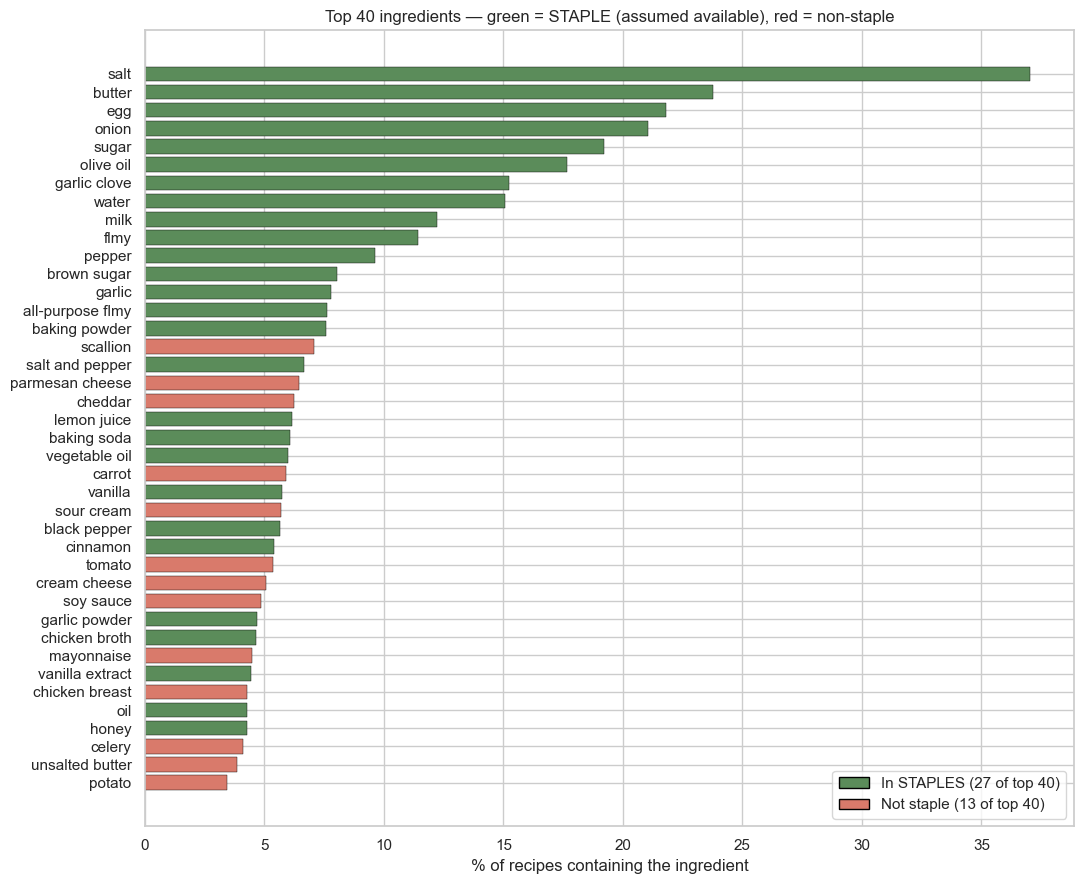

=== Of 38 STAPLES items, where do they rank? ===
  In top 50:   30 (79%)  — strong frequency justification
  In top 200:  34 (89%)  — at least defensible
  Never matched ('dead variants'): 4 — kept defensively for canonicalization robustness

=== Why we REJECTED frequent non-staples from the top 40 ===
   7.1%  scallion                    fresh produce; not pantry-stable
   6.4%  parmesan cheese             common but not universal; dairy
   6.2%  cheddar                     common but not universal; dairy
   5.9%  carrot                      fresh produce
   5.7%  sour cream                  dairy + not universal
   5.4%  tomato                      fresh produce
   5.1%  cream cheese                dairy + niche
   4.9%  soy sauce                   cuisine-specific (Asian-leaning)
   4.5%  mayonnaise                  common but debatable
   4.3%  chicken breast              fresh protein, not pantry
   4.1%  celery                      fresh produce
   3.9%  unsalted butter          

In [11]:
# Recipe-level ingredient frequency (how many recipes contain each)
recipes_with_ingr = Counter()
for ings in recipes["ingredients_parsed"]:
    canon = {normalize_ingredient(i) for i in ings if i}
    for c in canon:
        recipes_with_ingr[c] += 1

ranked = sorted(recipes_with_ingr.items(), key=lambda x: -x[1])
TOP_N = 40
top_n = ranked[:TOP_N]

# Bar chart: top-N ingredients, colored by staple membership
names = [n for n, _ in top_n]
pcts = [c / len(recipes) * 100 for _, c in top_n]
colors = ["#5b8c5a" if n in STAPLES else "#d97a6b" for n in names]

fig, ax = plt.subplots(figsize=(11, 9))
y = np.arange(len(names))
ax.barh(y, pcts, color=colors, edgecolor="black", linewidth=0.3)
ax.set_yticks(y); ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("% of recipes containing the ingredient")
ax.set_title(f"Top {TOP_N} ingredients — green = STAPLE (assumed available), red = non-staple")
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#5b8c5a", edgecolor="black", label=f"In STAPLES ({len([n for n in names if n in STAPLES])} of top {TOP_N})"),
    Patch(facecolor="#d97a6b", edgecolor="black", label=f"Not staple ({len([n for n in names if n not in STAPLES])} of top {TOP_N})"),
], loc="lower right")
plt.tight_layout(); plt.show()

# Numerical summary
print(f"=== Of {len(STAPLES)} STAPLES items, where do they rank? ===")
ranks = {name: i+1 for i, (name, _) in enumerate(ranked)}
in_top_50 = sum(1 for s in STAPLES if ranks.get(s, 999999) <= 50)
in_top_200 = sum(1 for s in STAPLES if ranks.get(s, 999999) <= 200)
unused = sum(1 for s in STAPLES if s not in ranks)
print(f"  In top 50:   {in_top_50} ({in_top_50/len(STAPLES):.0%})  — strong frequency justification")
print(f"  In top 200:  {in_top_200} ({in_top_200/len(STAPLES):.0%})  — at least defensible")
print(f"  Never matched ('dead variants'): {unused} — kept defensively for canonicalization robustness")

print(f"\n=== Why we REJECTED frequent non-staples from the top {TOP_N} ===")
rejection_rationale = {
    "scallion": "fresh produce; not pantry-stable",
    "parmesan cheese": "common but not universal; dairy",
    "cheddar": "common but not universal; dairy",
    "carrot": "fresh produce",
    "sour cream": "dairy + not universal",
    "tomato": "fresh produce",
    "cream cheese": "dairy + niche",
    "soy sauce": "cuisine-specific (Asian-leaning)",
    "mayonnaise": "common but debatable",
    "chicken breast": "fresh protein, not pantry",
    "celery": "fresh produce",
    "unsalted butter": "variant of `butter` (already a staple) — could add as variant",
    "potato": "fresh produce",
    "worcestershire sauce": "common-but-niche",
    "fresh parsley": "fresh herb",
    "fresh ground black pepper": "variant of `black pepper` — could add as variant",
    "parsley": "fresh herb",
    "chili powder": "cuisine-specific",
    "bacon": "not vegetarian-friendly; refrigerated",
    "red onion": "variant of `onion` (color-specific)",
    "nutmeg": "common in baking but niche",
    "cayenne pepper": "spice, cuisine-leaning",
    "mozzarella": "dairy, cuisine-specific",
    "granulated sugar": "variant of `sugar` — could add as variant",
}
non_staples_in_top = [n for n in names if n not in STAPLES]
for n in non_staples_in_top:
    rationale = rejection_rationale.get(n, "(no recorded rationale)")
    pct = recipes_with_ingr[n] / len(recipes) * 100
    print(f"  {pct:>4.1f}%  {n:<26}  {rationale}")

### Per-recipe coverage — is the set actually doing its job?

A staple set is only useful if it covers a meaningful fraction of typical recipes. We check: how many staples does the average recipe contain, and what fraction of recipes contain at least one staple?

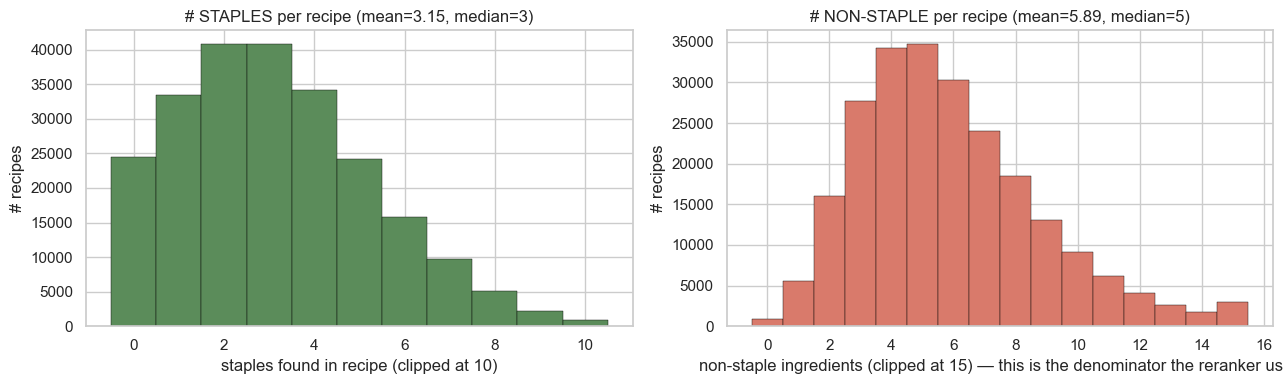

=== Coverage of 231,637 recipes by the 38-item STAPLES set ===
  % recipes with 0 staples:   10.6%
  % recipes with >= 1 staple:  89.4%
  % recipes with >= 3 staples: 57.4%
  % recipes with >= 5 staples: 25.1%

Staples explain ~35% of the average recipe's ingredient list.
That's the right order of magnitude — high enough to matter, not so high
that the staples-assumed view becomes trivial.

The ~11% of recipes with 0 staples are typically international or specialized
(sushi, niche desserts, sauces, etc.) — they're not the project's main concern.


In [12]:
# How many staples does each recipe contain?
spr = []
nspr = []
for ings in recipes["ingredients_parsed"]:
    canon = {normalize_ingredient(i) for i in ings if i}
    spr.append(len(canon & STAPLES))
    nspr.append(len(canon - STAPLES))
spr = np.array(spr)
nspr = np.array(nspr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.clip(spr, 0, 10), bins=range(12), edgecolor="black", linewidth=0.3, color="#5b8c5a", align="left")
axes[0].set_title(f"# STAPLES per recipe (mean={spr.mean():.2f}, median={np.median(spr):.0f})")
axes[0].set_xlabel("staples found in recipe (clipped at 10)")
axes[0].set_ylabel("# recipes")

axes[1].hist(np.clip(nspr, 0, 15), bins=range(17), edgecolor="black", linewidth=0.3, color="#d97a6b", align="left")
axes[1].set_title(f"# NON-STAPLE per recipe (mean={nspr.mean():.2f}, median={np.median(nspr):.0f})")
axes[1].set_xlabel("non-staple ingredients (clipped at 15) — this is the denominator the reranker uses")
axes[1].set_ylabel("# recipes")

plt.tight_layout(); plt.show()

print(f"=== Coverage of {len(recipes):,} recipes by the {len(STAPLES)}-item STAPLES set ===")
print(f"  % recipes with 0 staples:  {(spr == 0).mean()*100:>5.1f}%")
print(f"  % recipes with >= 1 staple: {(spr >= 1).mean()*100:>5.1f}%")
print(f"  % recipes with >= 3 staples:{(spr >= 3).mean()*100:>5.1f}%")
print(f"  % recipes with >= 5 staples:{(spr >= 5).mean()*100:>5.1f}%")
print()
print(f"Staples explain ~{spr.mean() / (spr.mean() + nspr.mean()):.0%} of the average recipe's ingredient list.")
print(f"That's the right order of magnitude — high enough to matter, not so high")
print(f"that the staples-assumed view becomes trivial.")
print()
print(f"The ~{(spr == 0).mean()*100:.0f}% of recipes with 0 staples are typically international or specialized")
print(f"(sushi, niche desserts, sauces, etc.) — they're not the project's main concern.")

## 5. Nutrition feasibility (Stage 2 nutrition)

Stage 2 will score `s_nutrition` by proximity to a target. For this to be informative, the macro space must (a) span a wide range and (b) have enough recipes near any plausible target.

Recipes pinned at the calorie cap (5000 kcal): 1,049 (0.45%)
Recipes pinned at PDV cap on fat_pdv       :    100 (0.04%)
Recipes pinned at PDV cap on sugar_pdv     :  2,846 (1.23%)
Recipes pinned at PDV cap on sodium_pdv    :    268 (0.12%)
Recipes pinned at PDV cap on protein_pdv   :     61 (0.03%)
Recipes pinned at PDV cap on satfat_pdv    :    338 (0.15%)
Recipes pinned at PDV cap on carbs_pdv     :     12 (0.01%)


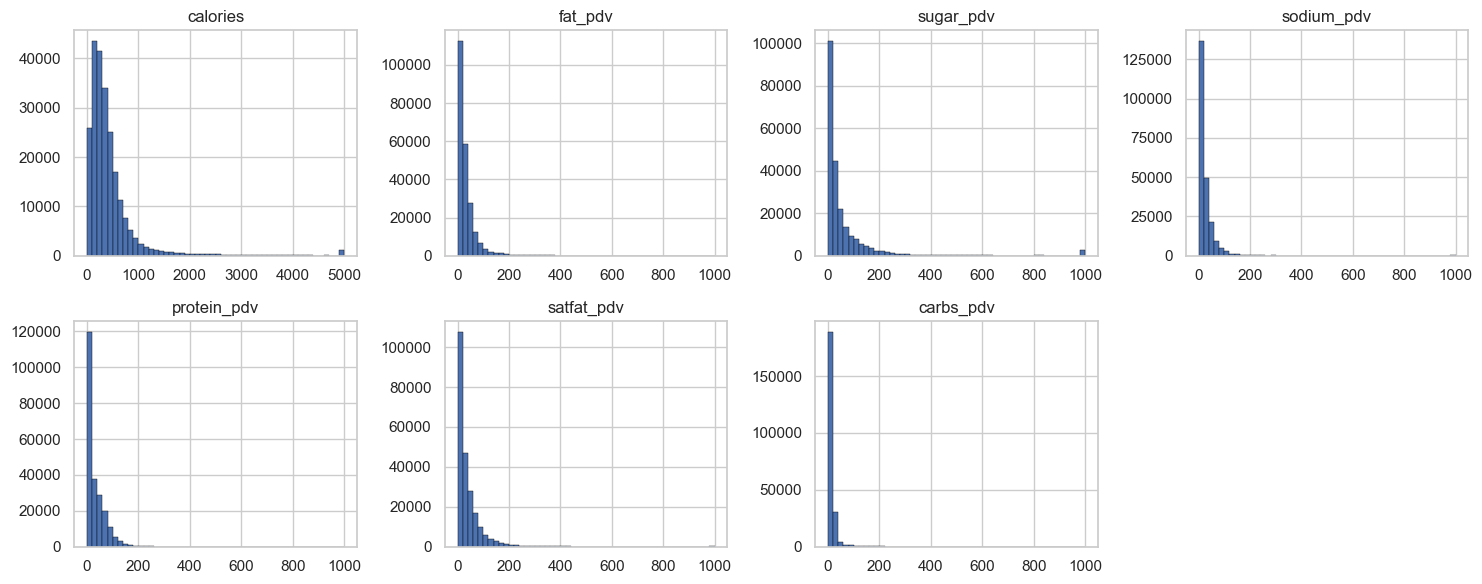

In [13]:
# Expand parsed nutrition into columns
nut_df = pd.DataFrame(
    [n if n else dict.fromkeys(NUTRITION_FIELDS, np.nan) for n in recipes["nutrition_parsed"]],
    index=recipes.index,
)

# How many recipes hit the clip cap?
calories_clipped = (nut_df["calories"] == 5000.0).sum()
print(f"Recipes pinned at the calorie cap (5000 kcal): {calories_clipped:,} "
      f"({calories_clipped/len(nut_df):.2%})")
for col in ["fat_pdv", "sugar_pdv", "sodium_pdv", "protein_pdv", "satfat_pdv", "carbs_pdv"]:
    n_pinned = (nut_df[col] == 1000.0).sum()
    print(f"Recipes pinned at PDV cap on {col:<14}: {n_pinned:>6,} ({n_pinned/len(nut_df):.2%})")

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(NUTRITION_FIELDS):
    axes[i].hist(nut_df[col].dropna(), bins=50, edgecolor="black", linewidth=0.3)
    axes[i].set_title(col); axes[i].set_xlabel("")
axes[-1].axis("off")
plt.tight_layout(); plt.show()

'Fitness lifter' target: 400–800 kcal, ≥40% protein PDV, ≤40% carbs PDV
Matching recipes: 33,981 / 231,637 (14.67%)

Sample matches:
  global gourmet  taco casserole                        457 kcal,  57% protein,   9% carbs
  i don t feel like cooking tonight  casserole          648 kcal,  54% protein,  16% carbs
  kitchen sink  egg bake                                794 kcal,  59% protein,   3% carbs
  mr  grant you took half veal prince orloff            511 kcal,  90% protein,   1% carbs
  open sesame  noodles                                  618 kcal,  56% protein,  24% carbs

Correlation matrix (nutrition fields):


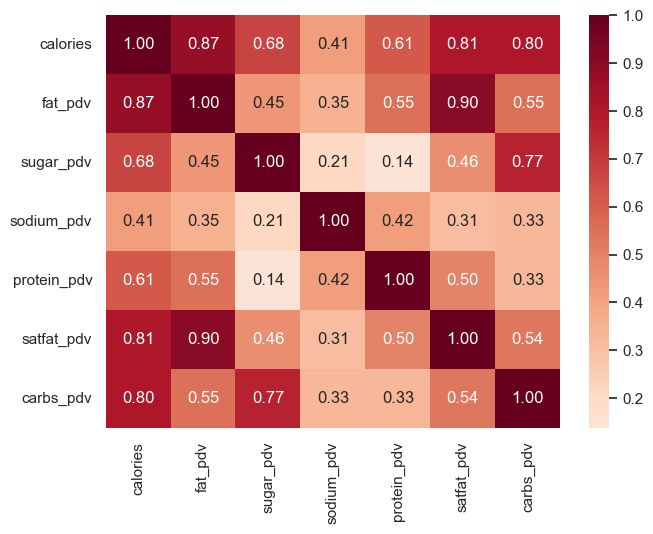

In [14]:
# How many recipes hit a realistic persona target?
# Persona: 'fitness lifter' — calories ≈ 600, high protein, low carbs
targets = {
    "calories": 600,
    "protein_pdv": 50,
    "carbs_pdv": 30,
}
tolerances = {
    "calories": (400, 800),
    "protein_pdv": (40, None),  # at least 40% PDV
    "carbs_pdv": (None, 40),    # at most 40% PDV
}

mask = pd.Series(True, index=nut_df.index)
for col, (lo, hi) in tolerances.items():
    if lo is not None: mask &= (nut_df[col] >= lo)
    if hi is not None: mask &= (nut_df[col] <= hi)

n_match = mask.sum()
print(f"'Fitness lifter' target: 400–800 kcal, ≥40% protein PDV, ≤40% carbs PDV")
print(f"Matching recipes: {n_match:,} / {mask.notna().sum():,} ({n_match/len(nut_df):.2%})")
print()
print("Sample matches:")
for _, r in recipes.loc[mask].head(5).iterrows():
    nut = r["nutrition_parsed"]
    print(f"  {r['name'][:50]:<50}  {nut['calories']:>5.0f} kcal, "
          f"{nut['protein_pdv']:>3.0f}% protein, {nut['carbs_pdv']:>3.0f}% carbs")

# Correlation structure
print("\nCorrelation matrix (nutrition fields):")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(nut_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
plt.tight_layout(); plt.show()

## 6. Dietary tag feasibility (Stage 2 diet)

The sanity check showed 11 of 17 desired dietary tags have >100 recipes — but several important ones (keto, paleo, whole30, lactose-free, halal, low-sugar) have **zero**. Stage 2's `s_diet` is a hard filter, so missing tags = restrictions we can't enforce from tags alone.

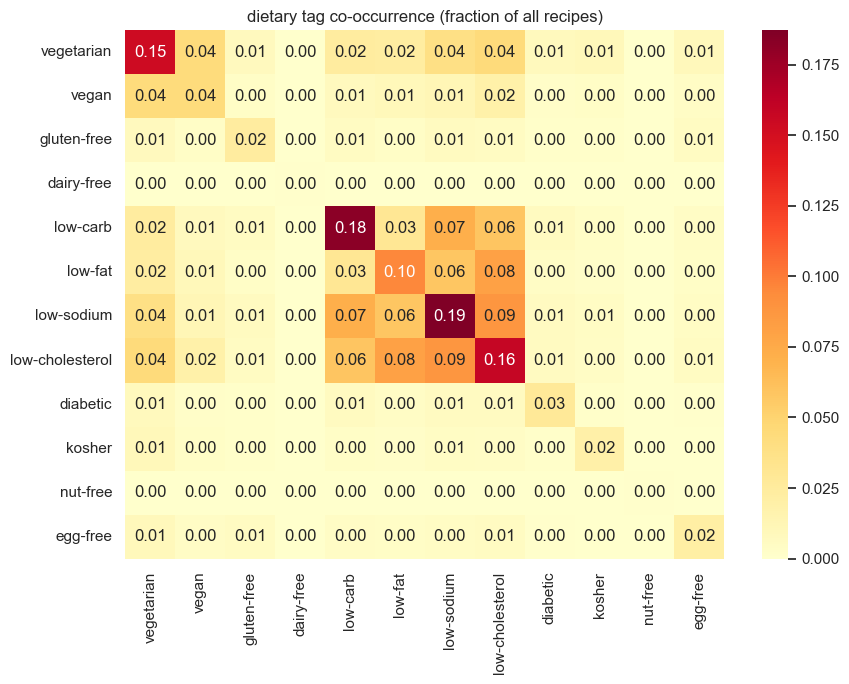

In [15]:
# Build a tag presence matrix for a few core dietary tags + check co-occurrence
TAGS_OF_INTEREST = [
    "vegetarian", "vegan", "gluten-free", "dairy-free",
    "low-carb", "low-fat", "low-sodium", "low-cholesterol",
    "diabetic", "kosher", "nut-free", "egg-free",
]
tag_matrix = pd.DataFrame(
    {t: recipes["tags_parsed"].apply(lambda L: t in L) for t in TAGS_OF_INTEREST}
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    tag_matrix.astype(int).T @ tag_matrix.astype(int) / len(tag_matrix),
    annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
)
ax.set_title("dietary tag co-occurrence (fraction of all recipes)")
plt.tight_layout(); plt.show()

In [16]:
# Consistency check: do 'vegan' tagged recipes actually have no animal products?
ANIMAL_PRODUCTS = {
    "butter", "egg", "eggs", "milk", "cheese", "chicken", "beef", "pork",
    "bacon", "ham", "fish", "salmon", "tuna", "shrimp", "yogurt",
    "cream", "sour cream", "honey", "gelatin", "lard",
}
vegan_recipes = recipes[recipes["tags_parsed"].apply(lambda L: "vegan" in L)]
print(f"Vegan-tagged recipes: {len(vegan_recipes):,}")

def has_animal(ing_list):
    canon = {normalize_ingredient(i) for i in ing_list}
    return bool(canon & ANIMAL_PRODUCTS)

# Sample to keep speed reasonable
check_sample = vegan_recipes.sample(min(2000, len(vegan_recipes)), random_state=42)
violators = check_sample["ingredients_parsed"].apply(has_animal).sum()
print(f"Of {len(check_sample):,} sampled vegan recipes, {violators:,} contain animal-product ingredients")
print(f"  -> tag-ingredient consistency: {1 - violators/len(check_sample):.1%}")
print()
print("Implication: tags are not perfectly reliable. For hard dietary filtering,")
print("we should AND a tag check with an ingredient-blocklist check.")

Vegan-tagged recipes: 10,012
Of 2,000 sampled vegan recipes, 62 contain animal-product ingredients
  -> tag-ingredient consistency: 96.9%

Implication: tags are not perfectly reliable. For hard dietary filtering,
we should AND a tag check with an ingredient-blocklist check.


## 7. Evaluation feasibility — Useful Recall ceiling

Useful Recall@K counts a recommendation as 'useful' only if it (a) appears in the user's held-out positives **and** (b) satisfies the user's constraints. We need to know whether the *held-out positives themselves* tend to satisfy plausible constraints — if they don't, Useful Recall has a low ceiling regardless of model quality.

In [17]:
# Build train/test, then check what fraction of held-out positives satisfy sample constraints
active_int = filter_active_users(interactions, min_ratings=5)
train, test = time_based_split(active_int, holdout_per_user=1)
print(f"Active users:        {active_int['user_id'].nunique():,}")
print(f"Train interactions:  {len(train):,}")
print(f"Held-out positives:  {len(test):,}  (one per user with at least one positive)")
print(f"Users with a held-out positive: {test['user_id'].nunique():,}")

# Join test with recipe metadata
test_recipes = test.merge(
    recipes[["id", "tags_parsed", "ingredients_parsed", "nutrition_parsed"]],
    left_on="recipe_id", right_on="id", how="left",
)

Active users:        22,018
Train interactions:  823,334
Held-out positives:  22,012  (one per user with at least one positive)
Users with a held-out positive: 22,012


In [18]:
# Of held-out positives, what fraction would satisfy simple example constraints?
def sat_vegetarian(tags): return isinstance(tags, list) and "vegetarian" in tags
def sat_under_600_kcal(nut): return isinstance(nut, dict) and nut["calories"] <= 600
def sat_quick(minutes): return minutes is not None and minutes <= 30

test_recipes["sat_veg"] = test_recipes["tags_parsed"].apply(sat_vegetarian)
test_recipes["sat_low_cal"] = test_recipes["nutrition_parsed"].apply(sat_under_600_kcal)
# Need 'minutes' — add via second merge
test_recipes = test_recipes.merge(recipes[["id", "minutes"]].rename(columns={"id": "recipe_id"}),
                                   on="recipe_id", how="left")
test_recipes["sat_quick"] = test_recipes["minutes"].apply(sat_quick)

for col, label in [
    ("sat_veg", "vegetarian-tagged"),
    ("sat_low_cal", "under 600 kcal"),
    ("sat_quick", "under 30 minutes"),
]:
    n = test_recipes[col].sum()
    print(f"Held-out positives satisfying '{label}': {n:>6,} ({n/len(test_recipes):.1%})")

both = (test_recipes["sat_veg"] & test_recipes["sat_low_cal"]).sum()
print(f"\nHeld-out positives satisfying BOTH 'vegetarian' AND '<600 kcal': {both:,} ({both/len(test_recipes):.1%})")
print(f"\nImplication: Useful Recall ceiling depends heavily on which constraints are imposed.")
print(f"A persona with restrictive macros + diet may see Useful Recall capped well below Recall.")

Held-out positives satisfying 'vegetarian-tagged':  3,335 (15.2%)
Held-out positives satisfying 'under 600 kcal': 17,648 (80.2%)
Held-out positives satisfying 'under 30 minutes':  8,156 (37.1%)

Held-out positives satisfying BOTH 'vegetarian' AND '<600 kcal': 2,962 (13.5%)

Implication: Useful Recall ceiling depends heavily on which constraints are imposed.
A persona with restrictive macros + diet may see Useful Recall capped well below Recall.


## 7b. Dual-track evaluation — warm vs cold items

The Food.com Kaggle dataset ships with two ways to construct evaluation sets:

1. **Our own time-based leave-one-out (warm-item LOO).** For each user in the authors' filtered train cohort, hold out their most-recent positive rating. Held-out items are recipes the model has *seen in train via other users*. This is the standard CF benchmark setup — predicts within the known recipe library.

2. **The authors' pre-split test (`interactions_test.csv`) — cold-item evaluation.** The authors hold out items that are essentially singletons in the whole dataset (median 1 rater in raw, 0 raters in train). Held-out items are recipes the model has *never seen rated by anyone*. This is a cold-item generalization test — predicts on unseen content.

These ask **different questions** and reward **different model types**. We use both. The chart below shows why they're not interchangeable.

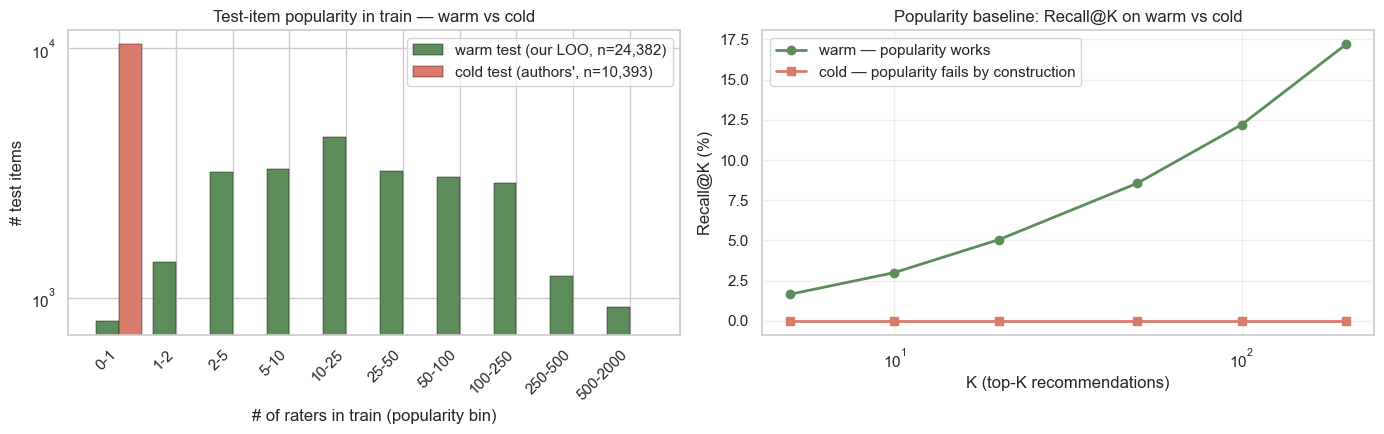

=== SUMMARY ===
Warm test — held-out items in train (have rating signal):
  Median popularity:  20 raters
  Items with >=1 rater in train: 23,575 / 24,382 (96.7%)
  Popularity Recall@10: 3.00%  ← meaningful baseline for CF models

Cold test — held-out items NOT in train (no rating signal):
  Median popularity:  0 raters
  Items with >=1 rater in train: 0 / 10,393 (0.0%)
  Popularity Recall@10: 0.00%  ← popularity CAN'T do cold-item by construction

=== IMPLICATIONS ===
1. Warm and cold are NOT interchangeable evaluation sets — they ask different questions.
2. Pure CF models (popularity, MF, EASE, BPR) work ONLY on warm — they need item co-occurrence.
3. Cold-item evaluation needs content-aware models (TF-IDF, Sentence-BERT, two-tower)
   that read recipe ingredients/text directly and can score unseen items.
4. Hybrid models should perform well on BOTH (they leverage both signals).
5. We report results on BOTH tracks — the project's story is about which models
   win which regime, and h

In [19]:
from src.data.loader import load_train_interactions, load_test_interactions
from src.models.popularity import PopularityRecommender
from src.eval.metrics import recall_at_k

# Build both evaluation tracks on the authors' filtered train cohort
full_train = load_train_interactions()
train_warm, test_warm = time_based_split(full_train, holdout_per_user=1)
test_cold = load_test_interactions()  # authors' cold-item test (positives only)

# Per-recipe popularity (number of distinct users who rated it in train_warm)
train_popularity = train_warm.groupby("recipe_id")["user_id"].nunique()

# For each test held-out item, what's its popularity in train_warm?
warm_pop = test_warm["recipe_id"].map(train_popularity).fillna(0)
cold_pop = test_cold["recipe_id"].map(train_popularity).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Chart 1: histogram of test-item popularity (log scale on x)
bins = [0, 1, 2, 5, 10, 25, 50, 100, 250, 500, 2000]
warm_hist, _ = np.histogram(warm_pop, bins=bins)
cold_hist, _ = np.histogram(cold_pop, bins=bins)
x = np.arange(len(bins)-1)
width = 0.4
axes[0].bar(x - width/2, warm_hist, width, label=f"warm test (our LOO, n={len(warm_pop):,})", color="#5b8c5a", edgecolor="black", linewidth=0.3)
axes[0].bar(x + width/2, cold_hist, width, label=f"cold test (authors', n={len(cold_pop):,})", color="#d97a6b", edgecolor="black", linewidth=0.3)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)], rotation=45, ha="right")
axes[0].set_xlabel("# of raters in train (popularity bin)")
axes[0].set_ylabel("# test items")
axes[0].set_yscale("log")
axes[0].set_title("Test-item popularity in train — warm vs cold")
axes[0].legend()

# Chart 2: popularity baseline Recall@10 on both tracks
model = PopularityRecommender().fit(train_warm)
K_VALS = [5, 10, 20, 50, 100, 200]
def eval_recall(truth_df, n_sample=2000, seed=42):
    truth = truth_df.groupby("user_id")["recipe_id"].agg(set).to_dict()
    rng = np.random.default_rng(seed)
    eval_uids = rng.choice(list(truth.keys()), size=min(n_sample, len(truth)), replace=False)
    results = []
    for k in K_VALS:
        hits = sum(1 for uid in eval_uids if any(r in truth[uid] for r in model.recommend(int(uid), k=k, exclude_seen=True)))
        results.append(hits / len(eval_uids))
    return results

warm_recalls = eval_recall(test_warm)
cold_recalls = eval_recall(test_cold)

axes[1].plot(K_VALS, [r*100 for r in warm_recalls], "o-", label="warm — popularity works", color="#5b8c5a", linewidth=2)
axes[1].plot(K_VALS, [r*100 for r in cold_recalls], "s-", label="cold — popularity fails by construction", color="#d97a6b", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_xlabel("K (top-K recommendations)")
axes[1].set_ylabel("Recall@K (%)")
axes[1].set_title("Popularity baseline: Recall@K on warm vs cold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"=== SUMMARY ===")
print(f"Warm test — held-out items in train (have rating signal):")
print(f"  Median popularity:  {warm_pop.median():.0f} raters")
print(f"  Items with >=1 rater in train: {(warm_pop >= 1).sum():,} / {len(warm_pop):,} ({(warm_pop>=1).mean()*100:.1f}%)")
print(f"  Popularity Recall@10: {warm_recalls[1]*100:.2f}%  ← meaningful baseline for CF models")
print()
print(f"Cold test — held-out items NOT in train (no rating signal):")
print(f"  Median popularity:  {cold_pop.median():.0f} raters")
print(f"  Items with >=1 rater in train: {(cold_pop >= 1).sum():,} / {len(cold_pop):,} ({(cold_pop>=1).mean()*100:.1f}%)")
print(f"  Popularity Recall@10: {cold_recalls[1]*100:.2f}%  ← popularity CAN'T do cold-item by construction")
print()
print(f"=== IMPLICATIONS ===")
print(f"1. Warm and cold are NOT interchangeable evaluation sets — they ask different questions.")
print(f"2. Pure CF models (popularity, MF, EASE, BPR) work ONLY on warm — they need item co-occurrence.")
print(f"3. Cold-item evaluation needs content-aware models (TF-IDF, Sentence-BERT, two-tower)")
print(f"   that read recipe ingredients/text directly and can score unseen items.")
print(f"4. Hybrid models should perform well on BOTH (they leverage both signals).")
print(f"5. We report results on BOTH tracks — the project's story is about which models")
print(f"   win which regime, and how the multi-constraint reranker improves both.")

## 8. Feasibility verdict per pillar

Verdicts based on the above analysis. ✅ = proceed as planned. ⚠️ = proceed with named mitigation. ❌ = restructure required.

| Pillar | Verdict | Evidence | Week 2 implication |
|---|---|---|---|
| **Stage 1 — CF candidate generation (warm-item)** | ✅ Go | Authors' filtered train cohort = 25K active users with 681K positive interactions. Popularity baseline gets Recall@10 ≈ 3% on warm items (a meaningful floor). | MF/EASE/BPR/hybrid should comfortably beat this. The 4-5 star rating skew means implicit-feedback models (BPR, EASE) are expected to outperform rating-magnitude prediction (MF). |
| **Stage 1 — Cold-item recommendation** | ✅ Go (content-aware models only) | Authors' pre-split test = 10K held-out items that are essentially singletons (0 in train via i-mapping). Popularity gets ~0% by construction. | Cold-item evaluation requires content-aware models (TF-IDF, Sentence-BERT, hybrid, two-tower). Pure CF models will (correctly) score ~0 on cold — this is expected, not a failure. |
| **Rating signal quality** | ⚠️ Caution | ~72% of ratings are 5-star and a sizeable fraction of active users use only 1–2 distinct values. The 4-star positive threshold is generous. | Use implicit-feedback ranking (BPR, EASE) — they treat ratings as binary positives, not as values. MF/ALS kept only as reference baseline. |
| **Stage 2 — pantry matching** | ✅ Go (with two distinct metrics) | `pantry_score` (non-staple overlap fraction) has median ~0.00 — most recipes have few non-staple items in a 25-item user pantry. This is fine *within-user* (it still ranks recipes from "best match" to "worst"). For the Useful Recall *threshold*, the count-based `missing ≤ 3` (~25% of recipes) is more usable and more intuitive than `s_pantry ≥ 0.5` (2.6% — too tight). | **Reranker uses `pantry_score`** (continuous). **Useful Recall uses `missing ≤ 3` non-staple items**. Personas list ~25 user-specific items; staples are project-wide (`src/utils/staples.py`). |
| **Stage 2 — nutrition targeting** | ✅ Go | Macro distributions are wide; even a tight 'fitness lifter' target matches ~thousands of recipes. Clip cap binds <0.5% of recipes. | Build `s_nutrition` with an exponential distance kernel as planned. Document the clipping in the proposal. |
| **Stage 2 — diet filtering** | ⚠️ Caution | 11 of 17 desired tags have coverage; **6 important tags have zero coverage** (keto, paleo, whole30, lactose-free, halal, low-sugar). Vegan-tag consistency is imperfect against ingredient checks. | For missing tags, **derive** from ingredients + nutrition (e.g. keto = `carbs_pdv < 10`). For supported tags, AND the tag check with an ingredient blocklist. Document derivation rules. |
| **Evaluation — Useful Recall** | ✅ Go (with framing) | Held-out positives satisfy realistic constraints at meaningful but non-trivial rates (e.g. ~15–20% vegetarian, ~80% <600 kcal). With the `missing ≤ 3` pantry condition, ~25% of recipes are pantry-feasible. Reported on both warm and cold tracks. | Report Recall and Useful Recall side by side, for both tracks. The *gap* between Recall and Useful Recall is the X-factor story; the *contrast* between warm and cold is the architecture story. |

## 9. Locked decisions coming out of this EDA

1. **Training cohort = authors' filtered train set (25K active users, 681K interactions).** We use `interactions_train.csv` from the Majumder et al. 2019 published split, which already filters to users with sufficient activity.
2. **Dual-track evaluation:**
   - **Track A — warm-item LOO**: we apply our own time-based leave-one-out (most-recent positive per user) on the authors' train. ~24K held-out positives. Tests all 8 Stage 1 models on standard CF benchmarking.
   - **Track B — cold-item**: we use the authors' `interactions_test.csv` as-is. 10K held-out positives, all on items the model has never seen. Tests cold-item generalization. Only content-aware models (TF-IDF, Sentence-BERT, hybrid, two-tower) can meaningfully compete.
3. **Implicit-feedback models (BPR, EASE) prioritized over rating-magnitude models (MF).** Rating distribution is top-heavy; magnitude prediction has little gradient. MF stays as reference baseline.
4. **Diet enforcement = tag OR derived rule, AND ingredient blocklist.** Document each derived rule in `docs/data_decisions.md`.
5. **Nutrition clipping at (5000 kcal, 1000% PDV) is fine** — affects <0.5% of recipes. Keep as default.
6. **Pantry — two distinct metrics:**
   - **Reranker score** = `pantry_score()` from `src/utils/staples.py`: `|non_staple ∩ user_pantry| / |non_staple|`. Median ~0.00 globally, but discriminates within-user. Continuous, [0,1].
   - **Useful Recall pantry condition** = `missing_count() ≤ 3`. More interpretable ("user only needs to buy 3 more things"), more usable threshold.
   - Personas need only enumerate ~25 user-specific items; 38 universal staples are project-wide. Vegan personas auto-drop dairy/eggs from staples.
7. **Useful Recall is the headline metric** — always report Recall and Useful Recall side by side, on both warm and cold tracks. Pantry condition: `missing ≤ 3` non-staple items.
8. **Cold-start angle is part of the project, not an afterthought.** The dual-track design lets us demonstrate (a) standard CF performance on warm items, (b) content-aware generalization on cold items, and (c) the multi-constraint reranker improving both. This is the architectural story.